# Introduction to the USGS Water Data APIs

The [USGS Water Data APIs](https://api.waterdata.usgs.gov/ogcapi/v0/) are the
modern, OGC-based replacement for the legacy NWIS web services. In Python they are
exposed through the `dataretrieval.waterdata` module, which will gradually replace
the older `dataretrieval.nwis` functions.

This notebook tours each new function. The NWIS shut-down timeline is still
uncertain, so we recommend migrating to the `waterdata` functions sooner rather
than later.

If you are coming from the R `dataRetrieval` package, the functions map across as
follows:

| R `dataRetrieval` | Python `dataretrieval.waterdata` |
| --- | --- |
| `read_waterdata_monitoring_location` | `get_monitoring_locations` |
| `read_waterdata_ts_meta` / `read_waterdata_combined_meta` | `get_time_series_metadata` / `get_combined_metadata` |
| `read_waterdata_parameter_codes` | `get_reference_table(collection="parameter-codes")` |
| `read_waterdata_daily` | `get_daily` |
| `read_waterdata_continuous` | `get_continuous` |
| `read_waterdata_field_measurements` | `get_field_measurements` |
| `read_waterdata_channel` | `get_channel` |
| `read_waterdata_latest_continuous` / `read_waterdata_latest_daily` | `get_latest_continuous` / `get_latest_daily` |
| `read_waterdata` (CQL) | the `filter` / `filter_lang` arguments on any function |
| `read_waterdata_metadata` | `get_reference_table` |
| `read_waterdata_samples` | `get_samples` |
| `read_waterdata_stats_por` / `read_waterdata_stats_daterange` | `get_stats_por` / `get_stats_date_range` |

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from dataretrieval import waterdata

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)

> **Return values.** Every `dataretrieval.waterdata` function returns a
> `(data, metadata)` tuple. The first element is a `pandas.DataFrame` (or a
> `geopandas.GeoDataFrame` when the service returns a geometry column); the
> second is a small metadata object describing the request. Throughout this
> notebook we unpack the tuple as `df, md = waterdata.get_...(...)`.

## New features

The new API endpoints each deliver a different type of USGS water data, and they
all share features the legacy services lacked.

### Flexible queries

The new functions expose **all** of the query parameters the API supports, each
defaulting to `None`. You do **not** need to (and usually should not) specify
them all. Filters are combined with a Boolean *AND*: passing both a list of
monitoring locations and a list of parameter codes returns only the
combinations of the two. Because every argument is named, your IDE can
autocomplete the options.

### Flexible columns returned

Use the `properties` argument to choose which columns come back. The full set of
available properties for a collection is published in that collection's schema,
e.g. <https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/queryables>.

In [2]:
# Ask for just a few columns instead of the full ~40-column record.
sites_info, _ = waterdata.get_monitoring_locations(
    monitoring_location_id="USGS-01491000",
    properties=[
        "monitoring_location_id",
        "site_type",
        "drainage_area",
        "monitoring_location_name",
    ],
)
sites_info.drop(columns="geometry")

Retrieving: monitoring-locations · 1 page · 1 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


,monitoring_location_id,site_type,drainage_area,monitoring_location_name
0,USGS-01491000,Stream,113.0,"CHOPTANK RIVER NEAR GREENSBORO, MD"


### API tokens

USGS now rate-limits requests per IP address per hour. If you hit the limit you
can request a free API token at <https://api.waterdata.usgs.gov/signup/>. Keep it
out of shared scripts and version control. (At the time of writing the Python
`dataretrieval` package does not yet wire a token into these calls; the rate
limits are generous for the queries below.)

### Contextual Query Language (CQL2)

The APIs accept [CQL2](https://www.loc.gov/standards/sru/cql/) expressions for
complex queries through the `filter` / `filter_lang` arguments. See the
[General retrieval and CQL2](#general-retrieval-and-cql2) section below.

### Simple features

Spatial collections return a `geometry` column, so `get_*` calls give you a
`geopandas.GeoDataFrame` that drops straight into geospatial workflows. Pass `skip_geometry=True` to get a plain `DataFrame`.

## Lessons learned

### Request many sites in one call

`dataretrieval` automatically splits a large request — many monitoring
locations, several parameter codes, or a complex filter — into URL-sized
sub-requests and recombines the results, and it can resume a long pull that hits
a rate limit or transient server error without refetching completed work. So
pass all your sites in one call rather than looping over them.

The main exception is **continuous** data, which is capped at 3 years per
request. See the *Continuous Data* notebook for large continuous pulls.

## New functions

### Monitoring location

`get_monitoring_locations` returns site metadata. To browse the service in a
web browser, visit
<https://api.waterdata.usgs.gov/ogcapi/v0/collections/monitoring-locations>.

A simple request for one known USGS site:

In [3]:
sites_info, _ = waterdata.get_monitoring_locations(
    monitoring_location_id="USGS-01491000"
)
print(f"{sites_info.shape[1]} columns returned")
sites_info.drop(columns="geometry").T

Retrieving: monitoring-locations · 1 page · 1 rows

44 columns returned


,0
monitoring_location_id,USGS-01491000
agency_code,USGS
agency_name,U.S. Geological Survey
monitoring_location_number,01491000
monitoring_location_name,"CHOPTANK RIVER NEAR GREENSBORO, MD"
district_code,24
country_code,US
country_name,United States of America
state_code,24
state_name,Maryland


Any returned column can also be used as an input filter. For example, to find
every stream site in Wisconsin:

In [4]:
sites_wi, _ = waterdata.get_monitoring_locations(
    state_name="Wisconsin",
    site_type="Stream",
)
print(f"{len(sites_wi)} Wisconsin stream sites")
sites_wi[["monitoring_location_id", "monitoring_location_name", "geometry"]].head()

Retrieving: monitoring-locations · 1 page · 2,815 rows

2815 Wisconsin stream sites


,monitoring_location_id,monitoring_location_name,geometry
0,ASCE-885512345000005,MLR 2 BATCH TEST - ASCE 005,POINT (-89.13328 44.17978)
1,ASCE-885512345000006,MLR 2 BATCH TEST - ASCE 006,POINT (-89.1725 44.11972)
2,ASCE-885512345000007,MLR 2 BATCH TEST - ASCE 007,POINT (-88.81972 44.09361)
3,USGS-04023120,"FLAG RIVER AT PORT WING, WI",POINT (-91.37367 46.78267)
4,USGS-04024025,"ST. LOUIS RIVER AT HWY. 23 ABOVE FOND DU LAC, MN",POINT (-92.28408 46.65844)


Because the result is a `GeoDataFrame`, plotting the locations is a one-liner.
For an interactive map, `folium` works well with the same data.

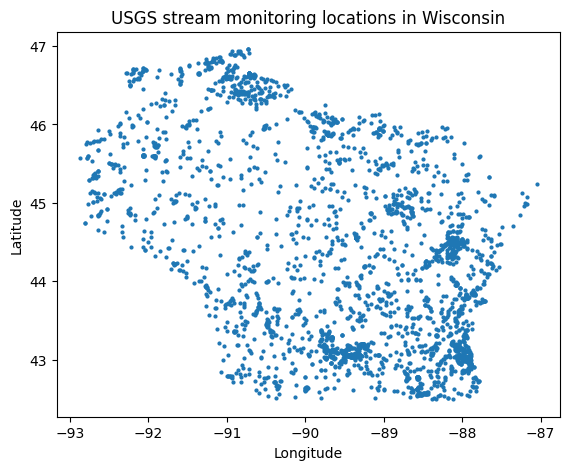

In [5]:
ax = sites_wi.plot(markersize=4, figsize=(7, 5))
ax.set_title("USGS stream monitoring locations in Wisconsin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

### Time series & combined metadata

`get_combined_metadata` joins the monitoring-location catalog
(`get_monitoring_locations`) with the time-series metadata
(`get_time_series_metadata`), returning one row per available time series with
both the site attributes and the series' period of record — a convenient "what
data is available" view.

In [6]:
ts_available, _ = waterdata.get_combined_metadata(
    monitoring_location_id="USGS-01491000",
    parameter_code=["00060", "00010"],
)
cols = ["parameter_name", "statistic_id", "begin", "end", "last_modified"]
ts_available[cols]

Retrieving: combined-metadata · 1 page · 11 rows

,parameter_name,statistic_id,begin,end,last_modified
0,Discharge,NaN,1948-01-15 13:00:00+00:00,2026-06-02 16:17:48+00:00,2026-06-08 19:11:01.917513+00:00
1,Discharge,NaN,1948-01-14 05:00:00+00:00,2025-04-13 04:00:00+00:00,2026-06-03 19:48:05.775076+00:00
2,"Temperature, water",00011,2023-04-20 22:30:00+00:00,2026-06-10 12:30:00+00:00,2026-06-10 08:37:28.953783+00:00
3,"Temperature, water",00002,2023-04-21 04:00:00+00:00,2026-06-08 04:00:00+00:00,2026-06-10 05:36:25.047701+00:00
4,Discharge,00003,1948-01-01 05:00:00+00:00,2026-06-08 04:00:00+00:00,2026-06-10 05:28:57.316660+00:00
5,"Temperature, water",00001,2023-04-21 04:00:00+00:00,2026-06-08 04:00:00+00:00,2026-06-10 05:36:24.955909+00:00
6,"Temperature, water",00003,2023-04-21 04:00:00+00:00,2026-06-08 04:00:00+00:00,2026-06-10 05:36:24.593292+00:00
7,Discharge,00011,1990-10-01 09:08:09+00:00,2026-06-10 11:15:00+00:00,2026-06-10 07:28:57.558099+00:00
8,"Temperature, water",00001,1988-10-01 04:00:00+00:00,2012-05-09 04:00:00+00:00,2020-08-27 16:15:01.888947+00:00
9,"Temperature, water",00002,2010-10-01 04:00:00+00:00,2012-05-09 04:00:00+00:00,2020-08-27 16:16:01.630091+00:00


### Parameter codes

Parameter-code descriptions come from the `parameter-codes` reference table:

In [7]:
pcode_info, _ = waterdata.get_reference_table(
    collection="parameter-codes",
    query={"id": "00660"},
)
pcode_info.T

Retrieving: parameter-codes · 1 page · 1 rows

,0
parameter_code,00660
parameter_name,"Orthophosphate, wf"
unit_of_measure,mg/l asPO4
parameter_group_code,NUT
parameter_description,"Orthophosphate, water, filtered, milligrams pe..."
medium,Water
statistical_basis,None
time_basis,None
weight_basis,None
particle_size_basis,None


### Daily values

`get_daily` returns daily values. Browse it at
<https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily>.

In [8]:
daily_data, _ = waterdata.get_daily(
    monitoring_location_id="USGS-01491000",
    parameter_code=["00060", "00010"],
    statistic_id="00003",
    time=["2023-10-01", "2024-09-30"],
)
daily_data[["time", "parameter_code", "value", "approval_status"]].head()

Retrieving: daily · 1 page · 730 rows

,time,parameter_code,value,approval_status
0,2023-10-01,00010,18.3,Approved
1,2023-10-01,00060,61.9,Approved
2,2023-10-02,00060,57.2,Approved
3,2023-10-02,00010,19.0,Approved
4,2023-10-03,00010,19.6,Approved


Notice the data come back in **long** format — one observation per row. Long
data are usually easier to work with; here we facet by `parameter_code`:

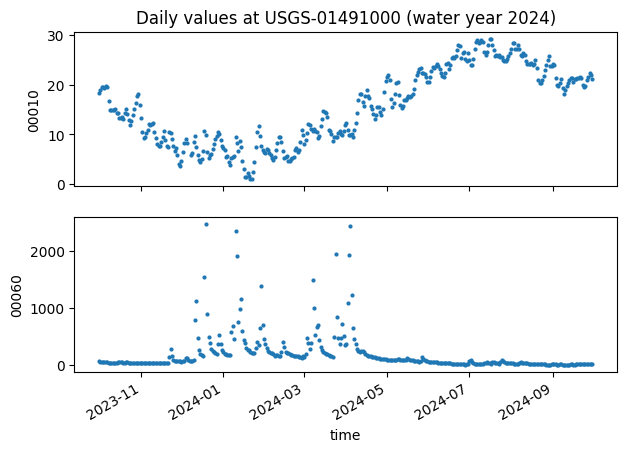

In [9]:
params = sorted(daily_data["parameter_code"].unique())
fig, axes = plt.subplots(len(params), 1, figsize=(7, 5), sharex=True)
for ax, pcode in zip(axes, params):
    sub = daily_data[daily_data["parameter_code"] == pcode]
    ax.scatter(sub["time"], sub["value"], s=4)
    ax.set_ylabel(pcode)
axes[0].set_title("Daily values at USGS-01491000 (water year 2024)")
axes[-1].set_xlabel("time")
fig.autofmt_xdate()
plt.show()

### Continuous

`get_continuous` returns instantaneous (sensor) values. Browse it at
<https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous>.

This service currently allows at most **3 years** of data per request; with no
`time` argument it returns the latest year. Continuous data have no geometry
column and do not support bounding-box queries. For large pulls, see the
*Continuous Data* notebook.

In [10]:
sensor_data, _ = waterdata.get_continuous(
    monitoring_location_id="USGS-01491000",
    parameter_code="00060",
    time="2024-09-01/2024-09-03",
)
sensor_data[["time", "parameter_code", "value", "approval_status"]].head()

Retrieving: continuous · 1 page · 193 rows

,time,parameter_code,value,approval_status
0,2024-09-01 00:00:00+00:00,00060,11.7,Approved
1,2024-09-01 00:15:00+00:00,00060,12.0,Approved
2,2024-09-01 00:30:00+00:00,00060,11.7,Approved
3,2024-09-01 00:45:00+00:00,00060,11.7,Approved
4,2024-09-01 01:00:00+00:00,00060,12.0,Approved


### Field measurements

`get_field_measurements` returns discrete field measurements, including
groundwater levels.

In [11]:
field_data, _ = waterdata.get_field_measurements(
    monitoring_location_id=[
        "USGS-451605097071701",
        "USGS-263819081585801",
    ],
    time=["2023-10-01", "2024-09-30"],
)
field_data[["time", "monitoring_location_id", "parameter_code", "value"]].head()

Retrieving: field-measurements · 1 page · 42 rows

,time,monitoring_location_id,parameter_code,value
0,2023-11-02 18:45:00+00:00,USGS-263819081585801,72019,27.55
1,2023-11-02 18:45:00+00:00,USGS-263819081585801,62610,-14.55
2,2023-11-02 18:45:00+00:00,USGS-263819081585801,62611,-15.68
3,2023-12-18 21:25:00+00:00,USGS-451605097071701,62610,1836.12
4,2023-12-18 21:25:00+00:00,USGS-451605097071701,72019,80.75


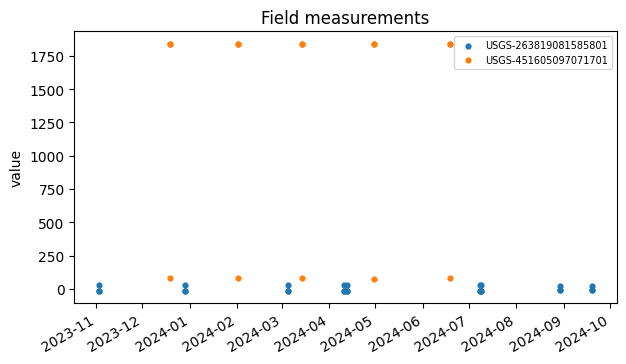

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for site, sub in field_data.groupby("monitoring_location_id"):
    ax.scatter(sub["time"], sub["value"], s=12, label=site)
ax.set_ylabel("value")
ax.set_title("Field measurements")
ax.legend(fontsize=7)
fig.autofmt_xdate()
plt.show()

### Channel measurements

`get_channel` returns channel-geometry measurements that accompany
`get_field_measurements`.

In [13]:
channel, _ = waterdata.get_channel(monitoring_location_id="USGS-02238500")
channel[["time", "channel_width", "channel_area", "channel_velocity"]].head()

Retrieving: channel-measurements · 1 page · 473 rows

,time,channel_width,channel_area,channel_velocity
0,1943-02-13 04:00:00+00:00,65.0,306,0.78
1,1943-02-26 04:00:00+00:00,47.0,187,1.07
2,1943-03-30 04:00:00+00:00,58.0,206,0.95
3,1943-05-01 04:00:00+00:00,45.0,200,0.78
4,1943-05-26 04:00:00+00:00,51.0,222,0.85


### Latest continuous & latest daily

`get_latest_continuous` and `get_latest_daily` have no NWIS equivalent — they
return the single most recent observation for each time series.

In [14]:
latest_uv, _ = waterdata.get_latest_continuous(
    monitoring_location_id="USGS-01491000",
    parameter_code="00060",
)
cols = ["time", "value", "approval_status", "parameter_code", "unit_of_measure"]
latest_uv[cols].T

Retrieving: latest-continuous · 1 page · 1 rows

,0
time,2026-06-10 13:15:00+00:00
value,12.2
approval_status,Provisional
parameter_code,00060
unit_of_measure,ft^3/s


In [15]:
latest_dv, _ = waterdata.get_latest_daily(
    monitoring_location_id="USGS-01491000",
    parameter_code="00060",
)
latest_dv[cols].T

Retrieving: latest-daily · 1 page · 1 rows

,0
time,2026-06-08 00:00:00
value,25.0
approval_status,Provisional
parameter_code,00060
unit_of_measure,ft^3/s


### General retrieval and CQL2

The OGC `get_*` functions accept a CQL2 expression through the `filter` /
`filter_lang` arguments, so even complex queries run against these same
functions — there is no separate "general retrieval" call.

CQL2 supports a wildcard via `LIKE` (`%` matches any trailing characters). This
is handy for hydrologic unit codes, which may be stored as `02070010` or as a
longer code beginning with those digits. To get every site whose HUC starts with
`02070010`:

Retrieving: monitoring-locations · 1 page · 2,354 rows

2354 sites in HUC 02070010


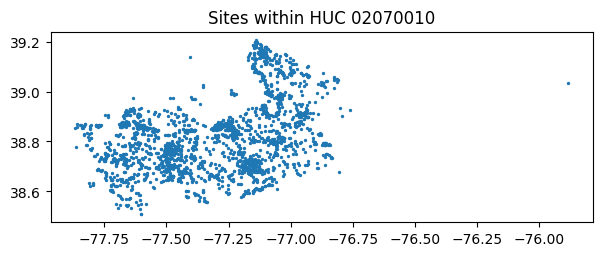

In [16]:
huc_sites, _ = waterdata.get_monitoring_locations(
    filter="hydrologic_unit_code LIKE '02070010%'",
    filter_lang="cql-text",
)
print(f"{len(huc_sites)} sites in HUC 02070010")
ax = huc_sites.plot(markersize=2, figsize=(7, 5))
ax.set_title("Sites within HUC 02070010")
plt.show()

> **Numeric filters.** Every queryable on the Water Data API is typed as a
> *string*, so an unquoted numeric comparison like `drainage_area > 1000` is
> rejected by the server (and quoting it gives a misleading lexicographic
> comparison). `dataretrieval` catches this and raises a `ValueError`:

In [17]:
try:
    waterdata.get_monitoring_locations(
        filter="drainage_area > 1000",
        filter_lang="cql-text",
    )
except ValueError as e:
    print(type(e).__name__, "->", str(e)[:120], "...")

ValueError -> Filter uses an unquoted numeric comparison against 'drainage_area' (``drainage_area > 1000``). Every queryable on the Wa ...


The recommended pattern is to filter on the string-valued attributes the server
understands (state, site type, HUC, …) and then do the **numeric** reduction in
pandas. For example, large-drainage stream sites in Wisconsin and Minnesota:

In [18]:
sites, _ = waterdata.get_monitoring_locations(
    state_name=["Wisconsin", "Minnesota"],
    site_type="Stream",
    properties=[
        "monitoring_location_id",
        "monitoring_location_name",
        "state_name",
        "drainage_area",
    ],
)
big = sites[pd.to_numeric(sites["drainage_area"], errors="coerce") > 1000]
print(f"{len(big)} of {len(sites)} WI/MN stream sites drain > 1000 sq mi")
big.drop(columns="geometry").head()

Retrieving: monitoring-locations · 1 page · 5,402 rows

225 of 5402 WI/MN stream sites drain > 1000 sq mi


,monitoring_location_id,monitoring_location_name,state_name,drainage_area
139,USGS-04023500,"ST. LOUIS RIVER NEAR CLOQUET, MN",Minnesota,3400.0
141,USGS-04024000,"ST. LOUIS RIVER AT SCANLON, MN",Minnesota,3430.0
426,USGS-04062011,"BRULE RIVER NEAR COMMONWEALTH, WI",Wisconsin,1020.0
427,USGS-04063000,"MENOMINEE RIVER NEAR FLORENCE, WI",Wisconsin,1760.0
456,USGS-04065106,"MENOMINEE RIVER AT NIAGARA, WI",Wisconsin,2470.0


### Reference tables

`get_reference_table` exposes a variety of metadata tables. Any returned column
can be filtered on. See the
*USGS Reference Lists* notebook for the full list of collections.

### Discrete samples

Discrete USGS water-quality data are served from a separate (non-OGC) endpoint
via `get_samples`. See the *Discrete water-quality samples* notebook.

### Daily data statistics

Pre-computed temporal summary statistics are available through `get_stats_por`
(day-of-year / month-of-year) and `get_stats_date_range` (calendar month, calendar
year, water year). See the *Daily statistics* notebook.

## More notes

### `limit` and paging

The `limit` argument sets how many rows come back **per page**, not the overall
total — by default `dataretrieval` pages through everything. You rarely need to
touch it; lowering it can help on a spotty connection.

### The `id` column

Each endpoint natively returns an `id` column, and that value is used as an input
to *other* endpoints under a different name (the monitoring-locations `id` is the
`monitoring_location_id` everywhere else). `dataretrieval` renames `id`
accordingly, but you can request the raw `id` column via `properties`:

In [19]:
site = "USGS-02238500"
renamed, _ = waterdata.get_monitoring_locations(
    monitoring_location_id=site,
    properties=["monitoring_location_id", "state_name", "country_name"],
)
raw_id, _ = waterdata.get_monitoring_locations(
    monitoring_location_id=site,
    properties=["id", "state_name", "country_name"],
)
print("renamed:", [c for c in renamed.columns if c != "geometry"])
print("raw id :", [c for c in raw_id.columns if c != "geometry"])

Retrieving: monitoring-locations · 1 page · 1 rows

Retrieving: monitoring-locations · 1 page · 1 rows

renamed: ['monitoring_location_id', 'state_name', 'country_name']
raw id : ['monitoring_location_id', 'state_name', 'country_name']


## More help

- Documentation: <https://doi-usgs.github.io/dataretrieval-python/>
- R package docs (source of these examples): <https://doi-usgs.github.io/dataRetrieval/>
- Issues / questions: <https://github.com/DOI-USGS/dataretrieval-python/issues>